Mounted at /content/drive
Files ready on the local disk

 Start Training...
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 202s 414ms/step - accuracy: 0.7565 - auc: 0.8326 - loss: 0.8832 - val_accuracy: 0.6374 - val_auc: 0.7051 - val_loss: 1.6952 - learning_rate: 1.0000e-04
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 211ms/step - accuracy: 0.8023 - auc: 0.8807 - loss: 0.7701 - val_accuracy: 0.7156 - val_auc: 0.8882 - val_loss: 0.8957 - learning_rate: 1.0000e-04
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 210ms/step - accuracy: 0.8241 - auc: 0.9027 - loss: 0.6920 - val_accuracy: 0.8098 - val_auc: 0.9081 - val_loss: 0.6826 - learning_rate: 1.0000e-04
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 210ms/step - accuracy: 0.8402 - auc: 0.9184 - loss: 0.6259 - val_accuracy: 0.8261 - val_auc: 0.9085 - val_loss: 0.6284 - learning_rate: 1.0000e-04
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 210ms/step - accuracy: 0.8558 - auc: 0.9316 - loss: 0.5673 - val_accuracy: 0.8449 - val_auc: 0.9248 - val_loss: 0.5

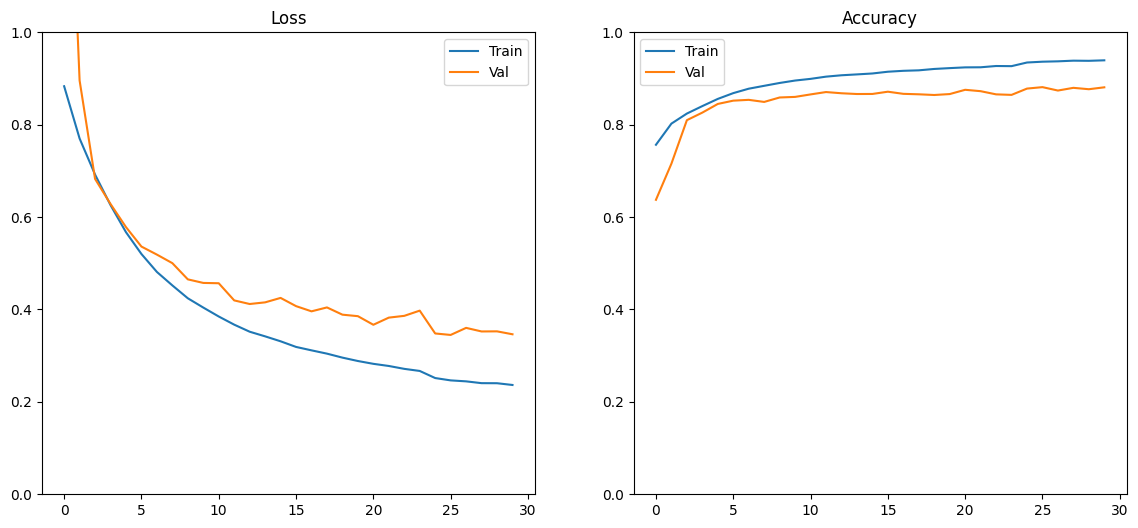


 Final evaluation on test set...
128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step
              precision    recall  f1-score   support

     Healthy       0.85      0.86      0.85     16391
       Tumor       0.86      0.85      0.85     16377

    accuracy                           0.85     32768
   macro avg       0.85      0.85      0.85     32768
weighted avg       0.85      0.85      0.85     32768



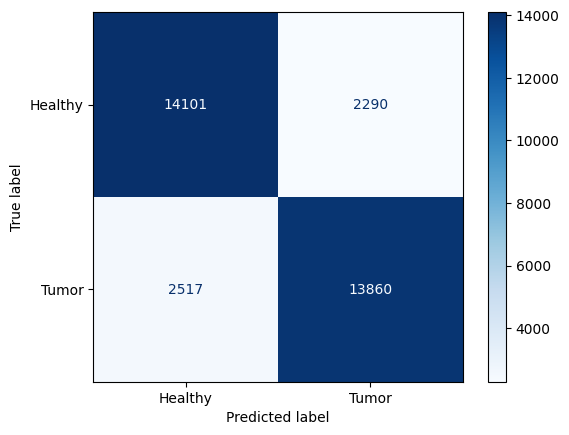

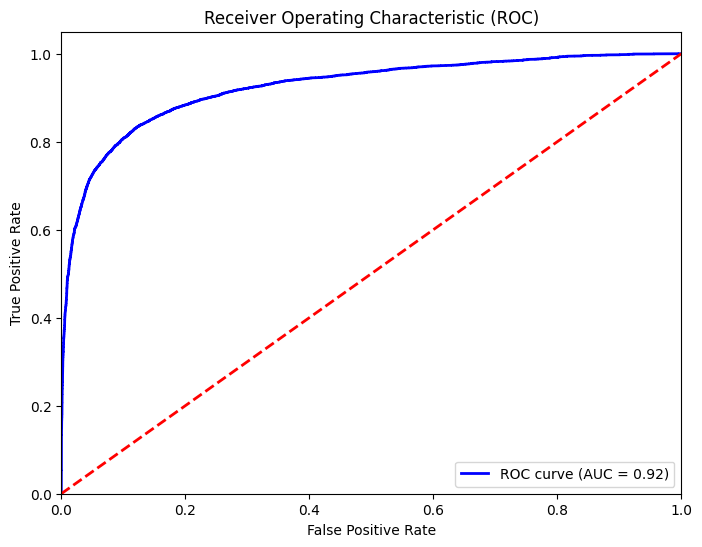

In [ ]:
from google.colab import drive
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tqdm import tqdm

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- FILE PREPARATION
!rm -rf /content/*.h5
for f in ['train_x','train_y','valid_x','valid_y','test_x','test_y']:
    src = f"/content/drive/MyDrive/PCam/camelyonpatch_level_2_split_{f}.h5"
    if os.path.exists(src):
        !cp "$src" /content/
print("Files ready on the local disk")

np.random.seed(42)
tf.random.set_seed(42)

# --- LOADING DATA ---
def load_to_ram(x_path, y_path, num_samples=80000):
    with h5py.File(y_path, 'r') as fy:
        y_all = fy['y'][:num_samples].reshape(-1, 1).astype('float32')
    with h5py.File(x_path, 'r') as fx:
        x_all = fx['x'][:num_samples] # Caricamento diretto per velocità
    return x_all, y_all

X_train, Y_train = load_to_ram('/content/camelyonpatch_level_2_split_train_x.h5',
                                    '/content/camelyonpatch_level_2_split_train_y.h5', 80000)
X_val, Y_val = load_to_ram('/content/camelyonpatch_level_2_split_valid_x.h5',
                                    '/content/camelyonpatch_level_2_split_valid_y.h5', 8000)

# --- G-CNN ARCHITECTURE ---
class P4LiftingConv2D(layers.Layer):
    def __init__(self, filters, kernel_size, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.kernel = self.add_weight(shape=(self.kernel_size, self.kernel_size, input_shape[-1], self.filters),
                                      initializer="glorot_uniform", name="kernel")
        self.bias = self.add_weight(shape=(self.filters * 4,), initializer="zeros", name="bias")

    def call(self, inputs):
        k = self.kernel
        full_k = tf.concat([k, tf.image.rot90(k, 1), tf.image.rot90(k, 2), tf.image.rot90(k, 3)], axis=-1)
        return tf.nn.conv2d(inputs, full_k, strides=1, padding='SAME') + self.bias

class GroupPool(layers.Layer):
    def call(self, inputs):
        shape = tf.shape(inputs)
        x = tf.reshape(inputs, [shape[0], shape[1], shape[2], 4, shape[3] // 4])
        return tf.reduce_max(x, axis=3)

# --- DATA AUGMENTATION ---
def augment(image, label):
    image = tf.image.resize_with_crop_or_pad(image, 80, 80)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    return image, label

def process_val(image, label):
    image = tf.image.resize_with_crop_or_pad(image, 80, 80)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# --- OPTIMIZED ARCHITECTURE ---
tf.keras.mixed_precision.set_global_policy('mixed_float16')
l2_val = 5e-4

def g_residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(l2_val))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=regularizers.l2(l2_val))(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
    return layers.Activation('relu')(layers.Add()([x, shortcut]))

def build_fast_gcnn():
    inputs = layers.Input(shape=(80, 80, 3)) # Input già croppato dalla CPU

    x = P4LiftingConv2D(filters=32, kernel_size=3)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    for f in [64, 128, 256]:
        x = g_residual_block(x, f)
        x = layers.MaxPooling2D()(x)
        x = layers.SpatialDropout2D(0.2)(x)

    x = GroupPool()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    return models.Model(inputs, outputs)

model = build_fast_gcnn()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')], jit_compile=True)

# --- TRAINING ---
BATCH_SIZE = 256 # Sfruttiamo la Mixed Precision al massimo

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train))\
    .shuffle(10000).map(augment, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val))\
    .map(process_val, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"\n Start Training (Batch Size: {BATCH_SIZE})...")
history = model.fit(train_ds, validation_data=val_ds, epochs=30,
                    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True),
                               callbacks.ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)])


# Saving the model
model.save('/content/drive/MyDrive/gcnn_model.keras')
print("Model saved successfully to Google Drive")

# Plotting figures about Loss and Accuracy
plt.figure(figsize=(14,6))
plt.subplot(1,2,1); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.title("Loss"); plt.ylim(0, 1.0); plt.legend()
plt.subplot(1,2,2); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.title("Accuracy"); plt.ylim(0, 1.0); plt.legend()
plt.show()



# ---  FINAL EVALUATION ---
print("\n Final evaluation on test set...")
with h5py.File('/content/camelyonpatch_level_2_split_test_x.h5','r') as fx, \
     h5py.File('/content/camelyonpatch_level_2_split_test_y.h5','r') as fy:
    X_test, Y_test = fx['x'][:], fy['y'][:].reshape(-1,1).astype('float32')

test_ds = tf.data.Dataset.from_tensor_slices((X_test, Y_test))\
    .map(process_val).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

y_pred_prob = model.predict(test_ds) # Get probabilities for ROC curve
y_pred = (y_pred_prob > 0.35).astype(int)
print(classification_report(Y_test, y_pred, target_names=["Healthy","Tumor"]))

cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy","Tumor"])
disp.plot(cmap='Blues', values_format='d')
plt.show()

# ROC Curve plotting
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()